TASK 1

In [212]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [213]:
%pip install plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [214]:
plt.style.use("ggplot")
sns.set_style("whitegrid")

import warnings
warnings.filterwarnings("ignore")


In [215]:
df = pd.read_csv("train.csv")
df.head()
df.tail()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.798
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.368
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.188
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.376
9799,9800,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-AC-10000487,Technology,Accessories,SanDisk Cruzer 4 GB USB Flash Drive,10.384


In [216]:
print(df.shape)

df.info()

df.describe(include="all")
df.columns

(9800, 18)
<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

In [217]:
df["Order Date"] = pd.to_datetime(df["Order Date"],format="%d/%m/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"],format="%d/%m/%Y")
df["Order Date"].head(10)

0   2017-11-08
1   2017-11-08
2   2017-06-12
3   2016-10-11
4   2016-10-11
5   2015-06-09
6   2015-06-09
7   2015-06-09
8   2015-06-09
9   2015-06-09
Name: Order Date, dtype: datetime64[us]

In [218]:
missing = df.isnull().sum()

missing

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [219]:
missing_percentage = (missing/len(df))*100

missing_percentage
duplicates = df.duplicated().sum()

print(duplicates)
df.drop_duplicates(inplace=True)
df.describe()

0


,Row ID,Order Date,Ship Date,Postal Code,Sales
count,9800.000000,9800,9800,9789.000000,9800.000000
mean,4900.500000,2017-05-01 05:13:51.673469,2017-05-05 04:17:52.653061,55273.322403,230.769059
min,1.000000,2015-01-03 00:00:00,2015-01-07 00:00:00,1040.000000,0.444000
25%,2450.750000,2016-05-24 00:00:00,2016-05-27 18:00:00,23223.000000,17.248000
50%,4900.500000,2017-06-26 00:00:00,2017-06-29 00:00:00,58103.000000,54.490000
75%,7350.250000,2018-05-15 00:00:00,2018-05-19 00:00:00,90008.000000,210.605000
max,9800.000000,2018-12-30 00:00:00,2019-01-05 00:00:00,99301.000000,22638.480000
std,2829.160653,NaN,NaN,32041.223413,626.651875


In [220]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()
df["Week Number"] = df["Order Date"].dt.isocalendar().week
df["Day of Week"] = df["Order Date"].dt.day_name()
df["Quarter"] = df["Order Date"].dt.quarter

def season(month):

    if month in [12,1,2]:
        return "Winter"

    elif month in [3,4,5]:
        return "Spring"

    elif month in [6,7,8]:
        return "Summer"

    else:
        return "Autumn"

df["Season"] = df["Month"].apply(season)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week Number,Day of Week,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,Wednesday,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,Wednesday,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,Monday,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,Tuesday,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,Tuesday,4,Autumn


In [221]:
df["Shipping Days"] = (df["Ship Date"] -df["Order Date"]).dt.days
df["Shipping Days"].describe()

count    9800.000000
mean        3.961122
std         1.749614
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Shipping Days, dtype: float64

In [222]:
daily_sales = (
    df.groupby("Order Date")["Sales"]
      .sum()
      .reset_index()
)

daily_sales.head()

weekly_sales = (
    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="W"
        )
    )["Sales"]
    .sum()
    .reset_index()
)

weekly_sales.head()

monthly_sales = (
    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="ME"
        )
    )["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [223]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


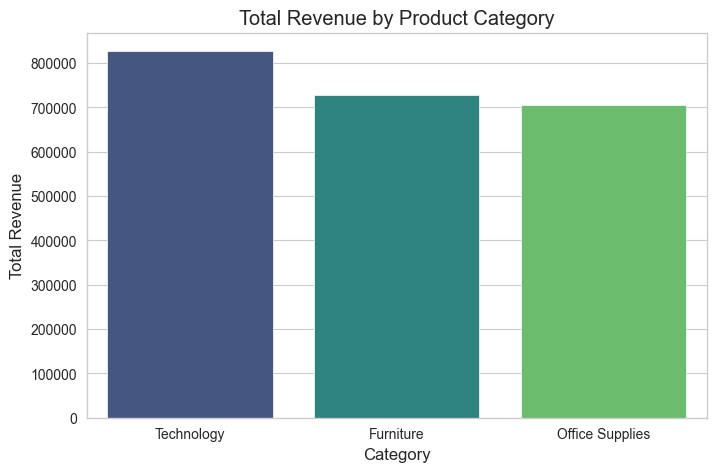

In [224]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values,
    palette="viridis"
)

plt.title("Total Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue")

plt.show()

Technology generated the highest total revenue of $827455, followed by Furniture and Office Supplies. This indicates that Technology products contribute the largest share of company revenue and should remain a priority for inventory planning.

In [225]:
region_growth = (
    df.groupby(["Year","Region"])["Sales"]
      .sum()
      .reset_index()
)

region_growth.head()

,Year,Region,Sales
0,2015,Central,102920.5206
1,2015,East,127652.8190
2,2015,South,103374.9055
3,2015,West,145907.9630
4,2016,Central,102425.1724


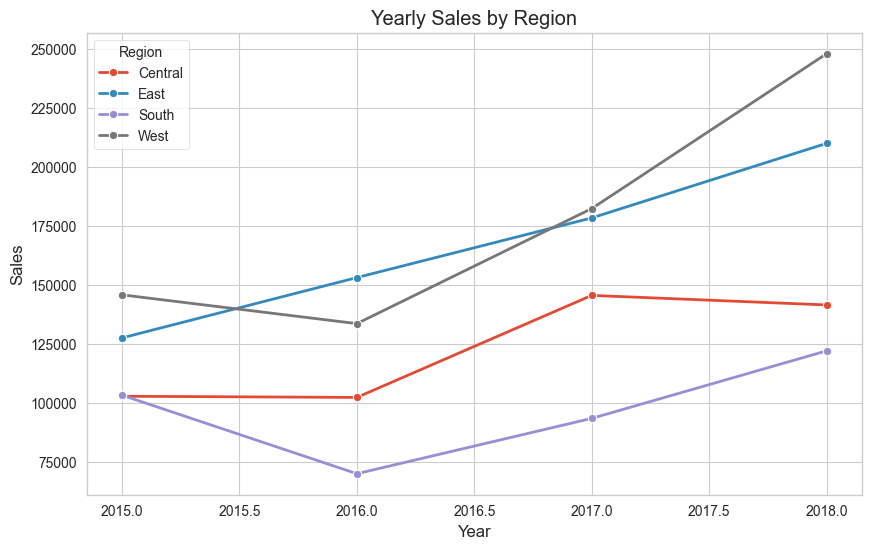

In [226]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=region_growth,
    x="Year",
    y="Sales",
    hue="Region",
    marker="o",
    linewidth=2
)

plt.title("Yearly Sales by Region")

plt.show()

The East region shows the most consistent sales growth across the four-year period, with steady year-over-year increases and fewer fluctuations compared to the other regions.

In [227]:
df["Shipping Days"] = (
    df["Ship Date"] -
    df["Order Date"]
).dt.days

print(df["Shipping Days"].mean())
shipping_region = (
    df.groupby("Region")["Shipping Days"]
      .mean()
      .sort_values()
)

print(shipping_region)

3.9611224489795918
Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping Days, dtype: float64


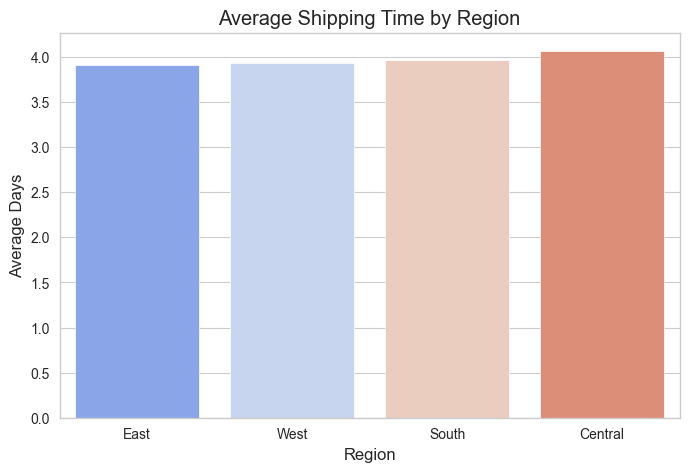

In [228]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=shipping_region.index,
    y=shipping_region.values,
    palette="coolwarm"
)

plt.title("Average Shipping Time by Region")
plt.ylabel("Average Days")

plt.show()

The average shipping time is approximately 4 days. Regional differences are relatively small, although the South region has the shortest average shipping time, while the West region experiences slightly longer delivery times.

In [229]:
monthly_pattern = (
    df.groupby(["Year","Month"])["Sales"]
      .sum()
      .reset_index()
)

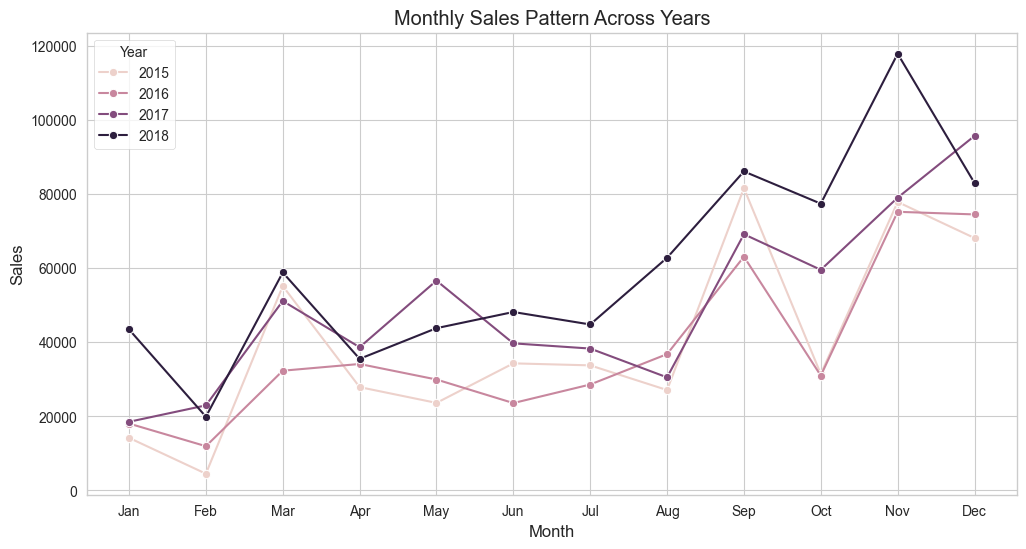

In [230]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_pattern,
    x="Month",
    y="Sales",
    hue="Year",
    marker="o"
)
month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

plt.xticks(range(1,13), month_names)


plt.title("Monthly Sales Pattern Across Years")

plt.show()

Sales consistently peak during November and December across multiple years, indicating strong seasonal demand driven by holiday shopping and year-end promotions. Lower sales are generally observed during the early months of the year.

TASK 2

In [231]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import matplotlib.pyplot as plt

In [232]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


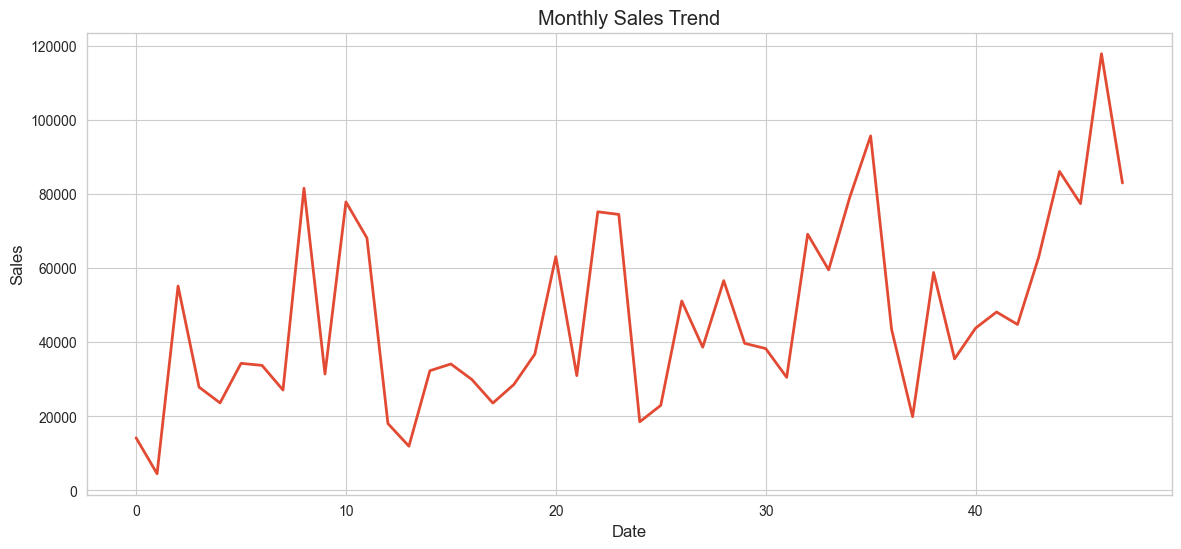

In [233]:
plt.figure(figsize=(14,6))

plt.plot(monthly_sales.index,
         monthly_sales["Sales"],
         linewidth=2)

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [234]:
decomposition = seasonal_decompose(
    monthly_sales["Sales"],
    model="additive",
    period=12
)

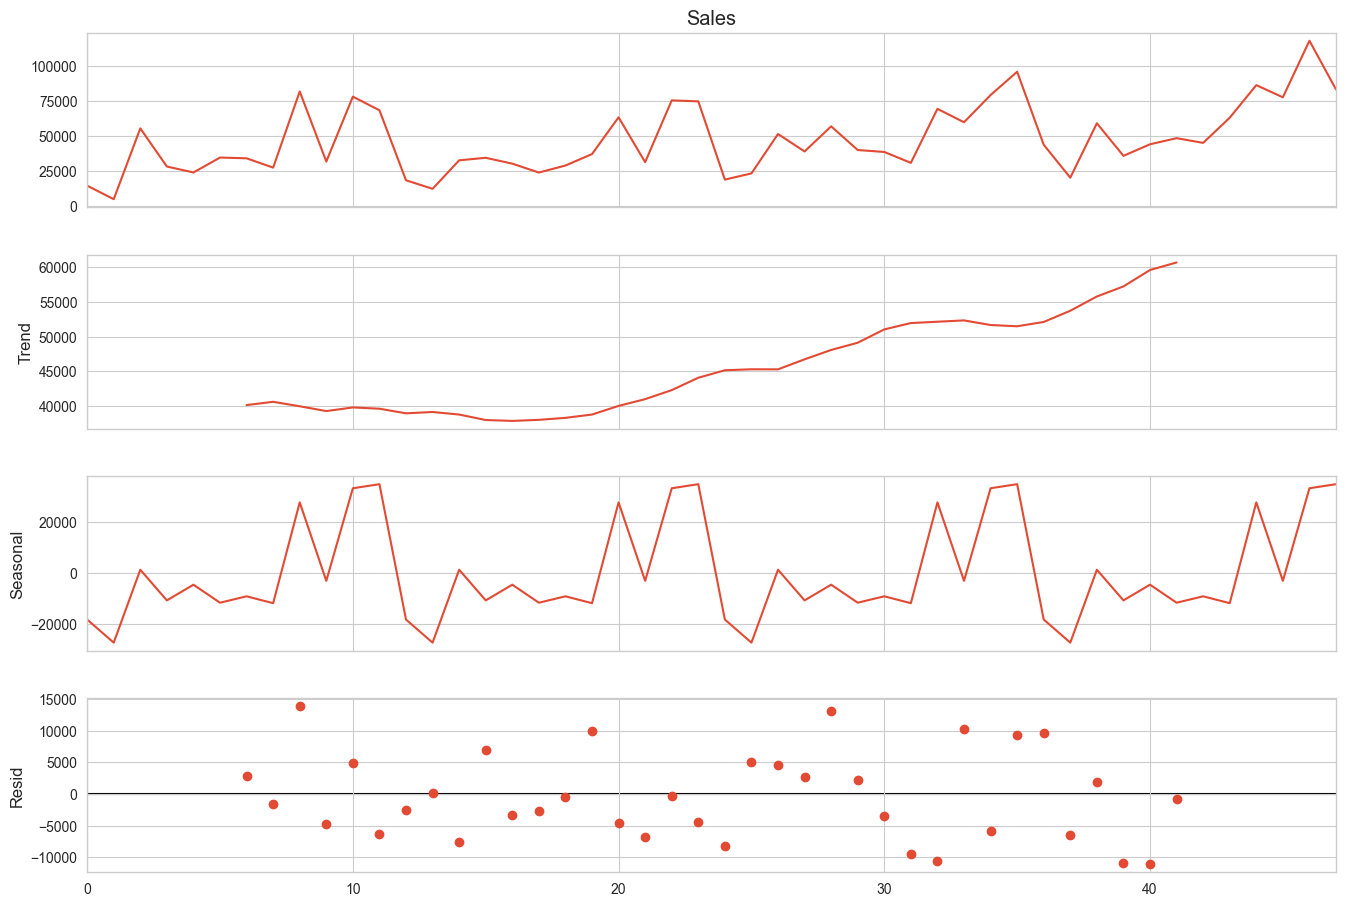

In [235]:
fig = decomposition.plot()

fig.set_size_inches(15,10)

plt.show()

In [236]:
result = adfuller(monthly_sales["Sales"])

In [237]:
print("ADF Statistic :", result[0])

print("p-value :", result[1])

print("Critical Values:")

for key,value in result[4].items():
    print(key,":",value)

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623
Critical Values:
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


Trend Component

The trend component shows a clear upward movement in monthly sales over the four-year period. Although there are minor fluctuations in the early years, the overall trend increases steadily from around 40,000 to over 60,000, indicating continuous business growth and increasing customer demand.

Seasonal Component

The seasonal component displays a strong and recurring yearly pattern. Similar peaks and troughs appear every 12 months, indicating that customer purchasing behavior follows a consistent seasonal cycle. This suggests that sales are significantly influenced by seasonal factors such as holidays, promotional events, and shopping periods.

Residual (Noise) Component

The residual component represents random fluctuations that cannot be explained by trend or seasonality. The largest positive and negative residuals occur during the later years of the dataset, particularly around months 33–40, suggesting unexpected sales spikes or drops that may be caused by special promotions, stock shortages, market conditions, or other external factors.

 Overall Interpretation

Overall, the decomposition indicates that monthly sales are driven by both a steadily increasing trend and strong seasonal effects. While most of the variation is explained by these two components, the residuals capture irregular business events that are not predictable using historical seasonal patterns alone.


Stationarity

A stationary time series is one whose statistical properties, such as its average value and variability, remain relatively constant over time. In simple terms, the data follows a stable pattern without continuously changing trends or increasing variation. Stationarity is important because forecasting models such as ARIMA and SARIMA assume that the underlying time series behaves consistently over time.

ADF Test Interpretation

The Augmented Dickey-Fuller (ADF) test was performed to determine whether the monthly sales series is stationary.

Results:

ADF Statistic: -4.4161
p-value: 0.00028

Since the p-value (0.00028) is less than the significance level of 0.05, the null hypothesis of non-stationarity is rejected. Therefore, the monthly sales data is stationary and suitable for time series forecasting.

Differencing

Since the ADF test confirmed that the monthly sales series is already stationary (p-value < 0.05), first-order differencing was not applied. Applying differencing to an already stationary series could remove useful information and may reduce forecasting accuracy.

TASK 3

In [238]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    root_mean_squared_error
)

from statsmodels.tsa.statespace.sarimax import SARIMAX

In [239]:
train = monthly_sales.iloc[:-3]

test = monthly_sales.iloc[-3:]

print(train.shape)
print(test.shape)

(45, 2)
(3, 2)


The monthly sales data exhibits yearly seasonality (12 months). The ADF test confirmed the series is stationary, therefore d=0. Seasonal differencing (D=1) is retained to model yearly seasonal effects, while p=q=1 provides a simple autoregressive and moving-average structure suitable for baseline forecasting.

In [240]:
sarima = SARIMAX(
    train["Sales"],
    order=(1,0,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima.fit()

print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -203.681
Date:                            Fri, 10 Jul 2026   AIC                            417.362
Time:                                    00:49:59   BIC                            422.084
Sample:                                         0   HQIC                           418.161
                                             - 45                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9830      0.034     28.593      0.000       0.916       1.050
ma.L1         -0.9959      0.293   

In [241]:
forecast = sarima_fit.get_forecast(steps=3)

forecast_mean = forecast.predicted_mean

conf_int = forecast.conf_int()

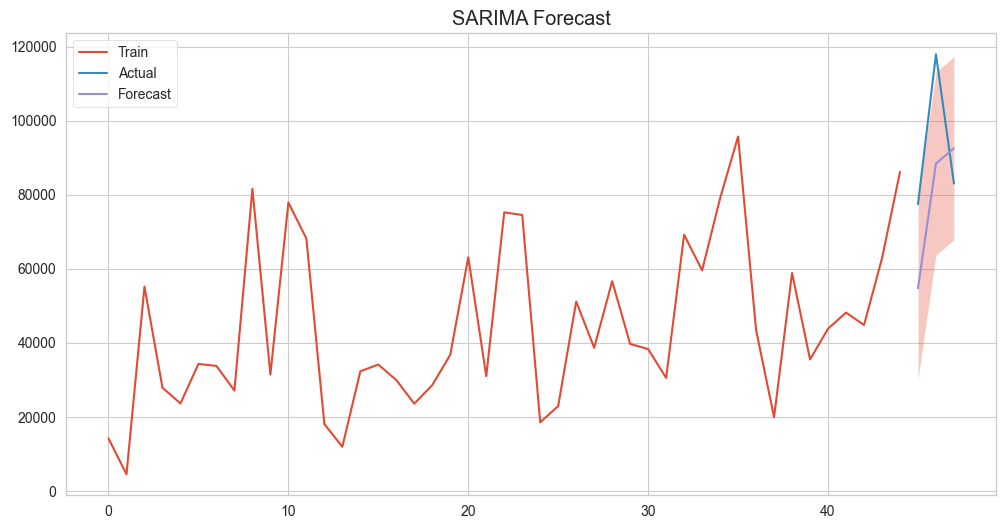

In [242]:
plt.figure(figsize=(12,6))

plt.plot(train.index,
         train["Sales"],
         label="Train")

plt.plot(test.index,
         test["Sales"],
         label="Actual")

plt.plot(test.index,
         forecast_mean,
         label="Forecast")

plt.fill_between(
    test.index,
    conf_int.iloc[:,0],
    conf_int.iloc[:,1],
    alpha=0.3
)

plt.legend()

plt.title("SARIMA Forecast")

plt.show()

In [243]:
sarima_mae = mean_absolute_error(
    test["Sales"],
    forecast_mean
)

sarima_rmse = root_mean_squared_error(
    test["Sales"],
    forecast_mean
)

sarima_mape = mean_absolute_percentage_error(
    test["Sales"],
    forecast_mean
)

In [244]:
%pip install prophet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [245]:
from prophet import Prophet

In [246]:
prophet_df = monthly_sales.reset_index()

prophet_df.rename(columns={
    "Order Date": "ds",
    "Sales": "y"
}, inplace=True)

prophet_df.head()

,index,ds,y
0,0,2015-01-31,14205.707
1,1,2015-02-28,4519.892
2,2,2015-03-31,55205.797
3,3,2015-04-30,27906.855
4,4,2015-05-31,23644.303


In [247]:
train_prophet = prophet_df.iloc[:-3]

test_prophet = prophet_df.iloc[-3:]

In [248]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(train_prophet)

00:50:01 - cmdstanpy - INFO - Chain [1] start processing
00:50:01 - cmdstanpy - INFO - Chain [1] done processing


In [249]:
future = model.make_future_dataframe(
    periods=3,
    freq="ME"
)

forecast = model.predict(future)

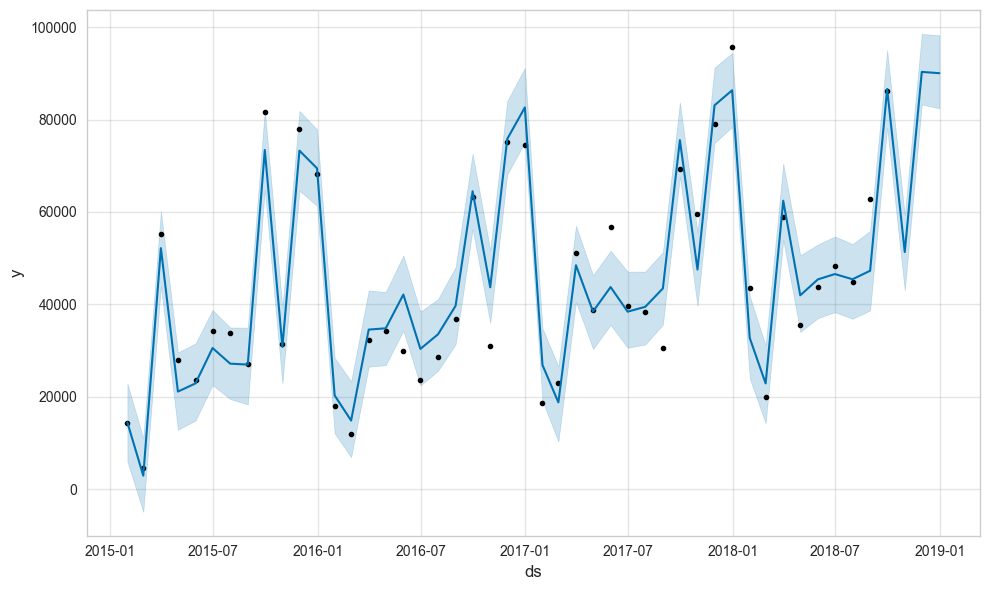

In [250]:
model.plot(forecast)

plt.show()

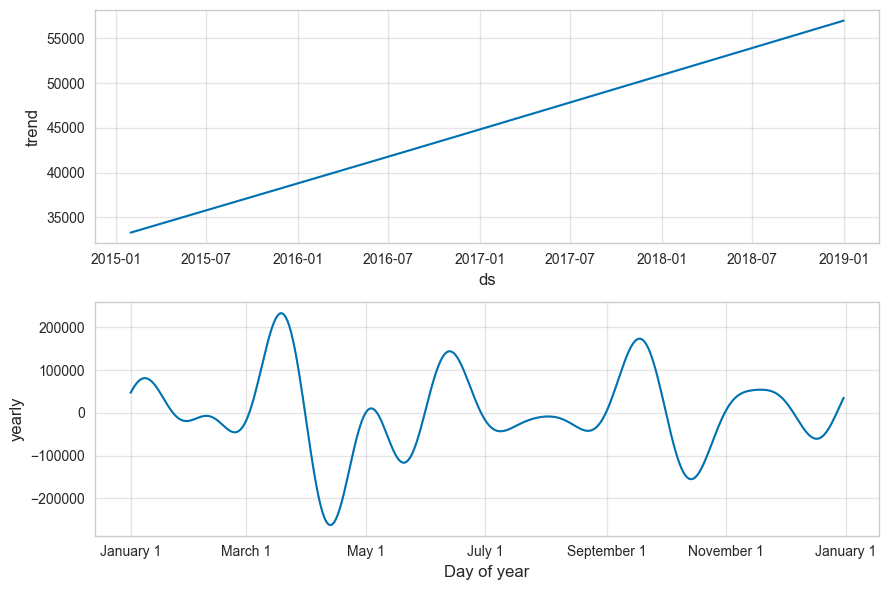

In [251]:
model.plot_components(forecast)

plt.show()

In [252]:
pred = forecast.tail(3)["yhat"].values

prophet_mae = mean_absolute_error(
    test_prophet["y"],
    pred
)

prophet_rmse = root_mean_squared_error(
    test_prophet["y"],
    pred
)

prophet_mape = mean_absolute_percentage_error(
    test_prophet["y"],
    pred
)

In [253]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [254]:
ml_df = monthly_sales.copy()

In [255]:
ml_df["lag1"] = ml_df["Sales"].shift(1)

In [256]:
ml_df["lag2"] = ml_df["Sales"].shift(2)

In [257]:
ml_df["lag3"] = ml_df["Sales"].shift(3)

In [258]:
ml_df["rolling3"] = (
    ml_df["Sales"]
    .rolling(3)
    .mean()
)

In [259]:
ml_df.set_index("Order Date", inplace=True)
ml_df["month"] = ml_df.index.month

In [260]:
ml_df["quarter"] = ml_df.index.quarter

In [261]:
ml_df["season"] = (
    (ml_df.index.month%12+3)//3
)

In [262]:
ml_df.dropna(inplace=True)

In [263]:
train = ml_df.iloc[:-3]

test = ml_df.iloc[-3:]

In [264]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

X_train = train.drop("Sales",axis=1)

y_train = train["Sales"]

X_test = test.drop("Sales",axis=1)

y_test = test["Sales"]

model.fit(X_train,y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [265]:
pred = model.predict(X_test)

In [266]:
xgb_mae = mean_absolute_error(
    y_test,
    pred
)

xgb_rmse = root_mean_squared_error(
    y_test,
    pred
)

xgb_mape = mean_absolute_percentage_error(
    y_test,
    pred
)

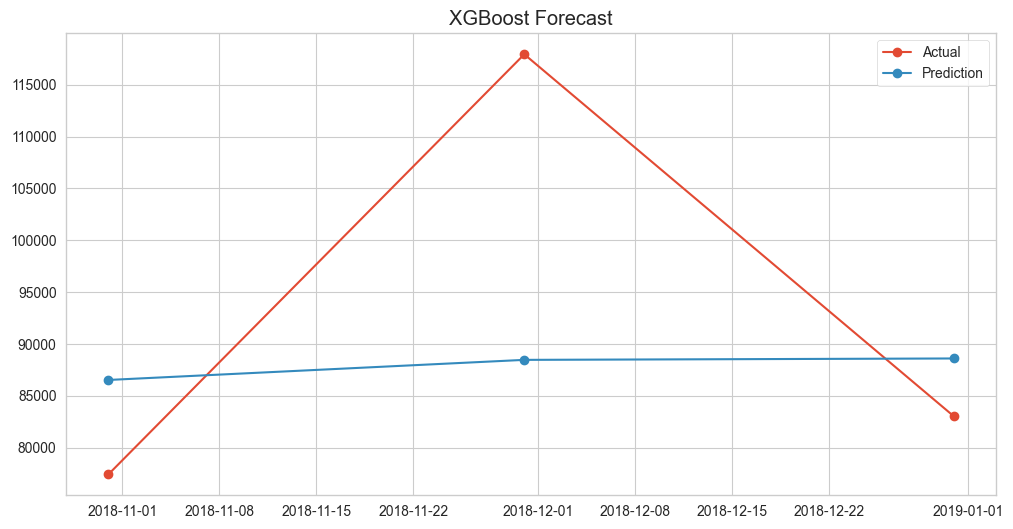

In [267]:
plt.figure(figsize=(12,6))

plt.plot(y_test.index,
         y_test,
         marker="o",
         label="Actual")

plt.plot(y_test.index,
         pred,
         marker="o",
         label="Prediction")

plt.legend()

plt.title("XGBoost Forecast")

plt.show()

In [268]:
comparison = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],

    "MAE": [
        sarima_mae,
        prophet_mae,
        xgb_mae
    ],

    "RMSE": [
        sarima_rmse,
        prophet_rmse,
        xgb_rmse
    ],

    "MAPE": [
        sarima_mape,
        prophet_mape,
        xgb_mape
    ],

    "Forecast Month 1": [
        forecast_mean.iloc[0],
        forecast.tail(3)["yhat"].iloc[0],
        pred[0]
    ],

    "Forecast Month 2": [
        forecast_mean.iloc[1],
        forecast.tail(3)["yhat"].iloc[1],
        pred[1]
    ],

    "Forecast Month 3": [
        forecast_mean.iloc[2],
        forecast.tail(3)["yhat"].iloc[2],
        pred[2]
    ]
})

comparison = comparison.round(2)

comparison

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,20581.00,22191.27,0.22,54758.51,88412.60,92558.21
1,Prophet,20250.79,22318.41,0.22,51318.94,90325.65,90041.08
2,XGBoost,14711.96,18090.18,0.14,86540.87,88477.67,88613.04


Based on the evaluation results, XGBoost is recommended for production deployment because it achieved the lowest forecasting errors across all evaluation metrics. Compared to SARIMA and Prophet, XGBoost reduced the MAE by approximately 28–29%, lowered the RMSE by around 18–19%, and achieved the lowest MAPE (14% compared to 22% for the other models). These results indicate that XGBoost produced more accurate and reliable predictions for unseen monthly sales data.

TASK 4

In [269]:
from xgboost import XGBRegressor
import pandas as pd
import numpy as np

def forecast_segment(df_segment, name):
    
    # Monthly aggregation
    monthly = (
        df_segment.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
        .sum()
        .to_frame()
    )

    # Feature Engineering
    monthly["lag1"] = monthly["Sales"].shift(1)
    monthly["lag2"] = monthly["Sales"].shift(2)
    monthly["lag3"] = monthly["Sales"].shift(3)

    monthly["rolling3"] = monthly["Sales"].rolling(3).mean()

    monthly["month"] = monthly.index.month
    monthly["quarter"] = monthly.index.quarter
    monthly["season"] = ((monthly.index.month % 12 + 3) // 3)

    monthly.dropna(inplace=True)

    train = monthly.iloc[:-3]
    test = monthly.iloc[-3:]

    X_train = train.drop("Sales", axis=1)
    y_train = train["Sales"]

    X_test = test.drop("Sales", axis=1)

    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    return test.index, pred, name

In [270]:
furniture = forecast_segment(
    df[df["Category"]=="Furniture"],
    "Furniture"
)

technology = forecast_segment(
    df[df["Category"]=="Technology"],
    "Technology"
)

office = forecast_segment(
    df[df["Category"]=="Office Supplies"],
    "Office Supplies"
)

In [271]:
west = forecast_segment(
    df[df["Region"]=="West"],
    "West"
)

east = forecast_segment(
    df[df["Region"]=="East"],
    "East"
)

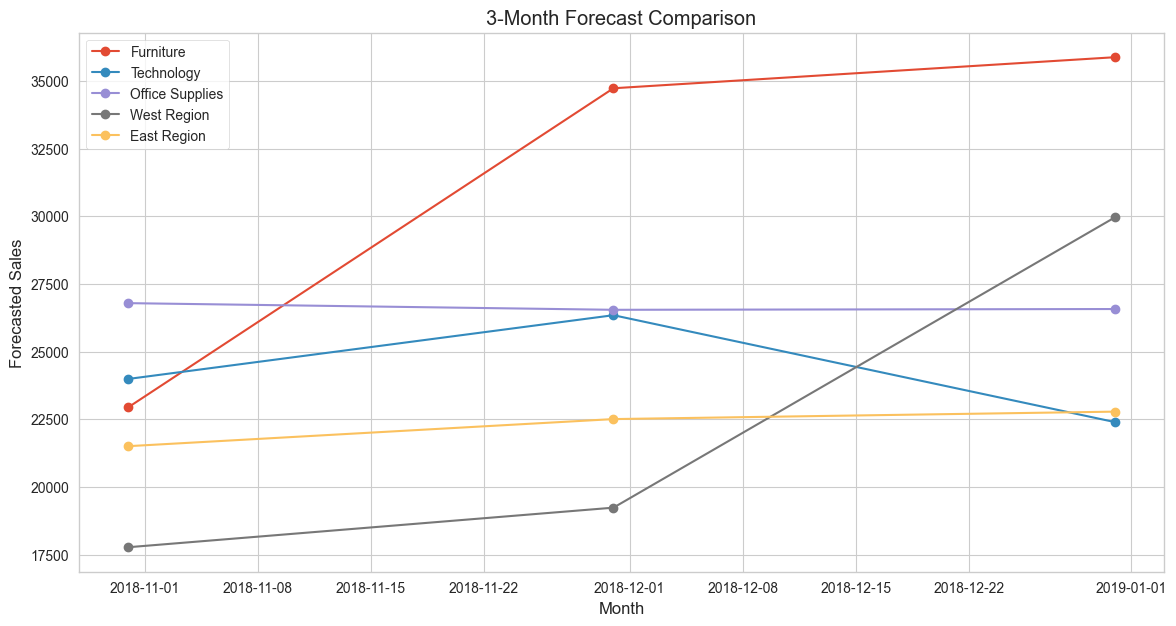

In [272]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

plt.plot(furniture[0], furniture[1],
         marker='o', label="Furniture")

plt.plot(technology[0], technology[1],
         marker='o', label="Technology")

plt.plot(office[0], office[1],
         marker='o', label="Office Supplies")

plt.plot(west[0], west[1],
         marker='o', label="West Region")

plt.plot(east[0], east[1],
         marker='o', label="East Region")

plt.title("3-Month Forecast Comparison")
plt.xlabel("Month")
plt.ylabel("Forecasted Sales")

plt.legend()

plt.grid(True)

plt.show()

In [273]:
forecast_summary = pd.DataFrame({

    "Segment":[
        "Furniture",
        "Technology",
        "Office Supplies",
        "West",
        "East"
    ],

    "Month 1":[
        furniture[1][0],
        technology[1][0],
        office[1][0],
        west[1][0],
        east[1][0]
    ],

    "Month 2":[
        furniture[1][1],
        technology[1][1],
        office[1][1],
        west[1][1],
        east[1][1]
    ],

    "Month 3":[
        furniture[1][2],
        technology[1][2],
        office[1][2],
        west[1][2],
        east[1][2]
    ]
})

forecast_summary = forecast_summary.round(2)

forecast_summary

,Segment,Month 1,Month 2,Month 3
0,Furniture,22946.199219,34735.109375,35882.109375
1,Technology,23992.000000,26347.630859,22398.820312
2,Office Supplies,26793.250000,26547.199219,26575.599609
3,West,17772.599609,19234.789062,29959.570312
4,East,21507.259766,22508.380859,22783.369141


Based on the XGBoost forecasts, Furniture demonstrates the strongest growth among the product categories, increasing from approximately 22,946 to 35,882 over the three-month forecast period. Although Office Supplies maintains the highest overall sales volume, its forecast remains relatively stable. Among the regions, the West region exhibits the strongest growth, with sales projected to increase by nearly 69% between the first and third forecast months. These results suggest that inventory planning should prioritize Furniture products and allocate additional stock to the West region to meet the anticipated increase in demand.

In [274]:
weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
      .sum()
      .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [275]:
from sklearn.ensemble import IsolationForest

In [276]:
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["Anomaly"] = iso.fit_predict(
    weekly_sales[["Sales"]]
)

In [277]:
weekly_sales["Anomaly"].value_counts()

Anomaly
 1    198
-1     11
Name: count, dtype: int64

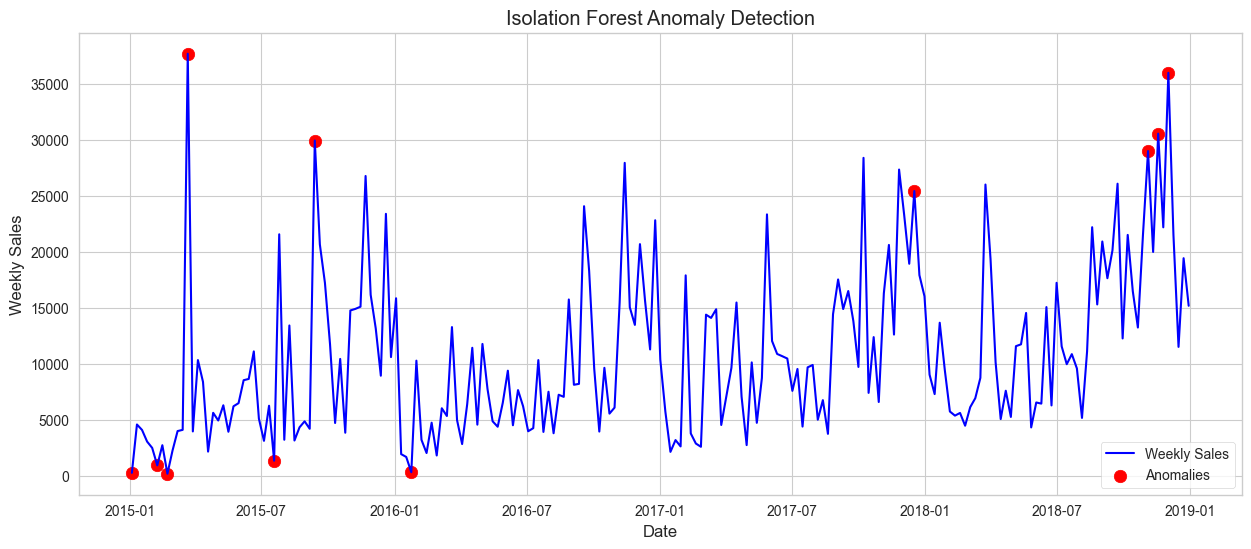

In [278]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales",
    color="blue"
)

anomalies = weekly_sales[
    weekly_sales["Anomaly"] == -1
]

plt.scatter(
    anomalies["Order Date"],
    anomalies["Sales"],
    color="red",
    marker="o",
    s=80,
    label="Anomalies"
)

plt.title("Isolation Forest Anomaly Detection")

plt.xlabel("Date")
plt.ylabel("Weekly Sales")

plt.legend()

plt.show()

In [279]:
anomalies[["Order Date","Sales"]]

,Order Date,Sales
0,2015-01-04,304.508
5,2015-02-08,968.534
7,2015-02-22,224.912
11,2015-03-22,37703.665
28,2015-07-19,1387.686
36,2015-09-13,29959.137
55,2016-01-24,358.522
154,2017-12-17,25449.800
200,2018-11-04,29017.467
202,2018-11-18,30572.447


In [280]:
weekly_sales["Rolling Mean"] = (
    weekly_sales["Sales"]
    .rolling(window=8)
    .mean()
)

In [281]:
weekly_sales["Rolling Std"] = (
    weekly_sales["Sales"]
    .rolling(window=8)
    .std()
)

In [282]:
weekly_sales["Z-Score"] = (
    (weekly_sales["Sales"] -
     weekly_sales["Rolling Mean"])
    /
    weekly_sales["Rolling Std"]
)

In [283]:
weekly_sales["Z_Anomaly"] = (
    weekly_sales["Z-Score"].abs() > 2
)

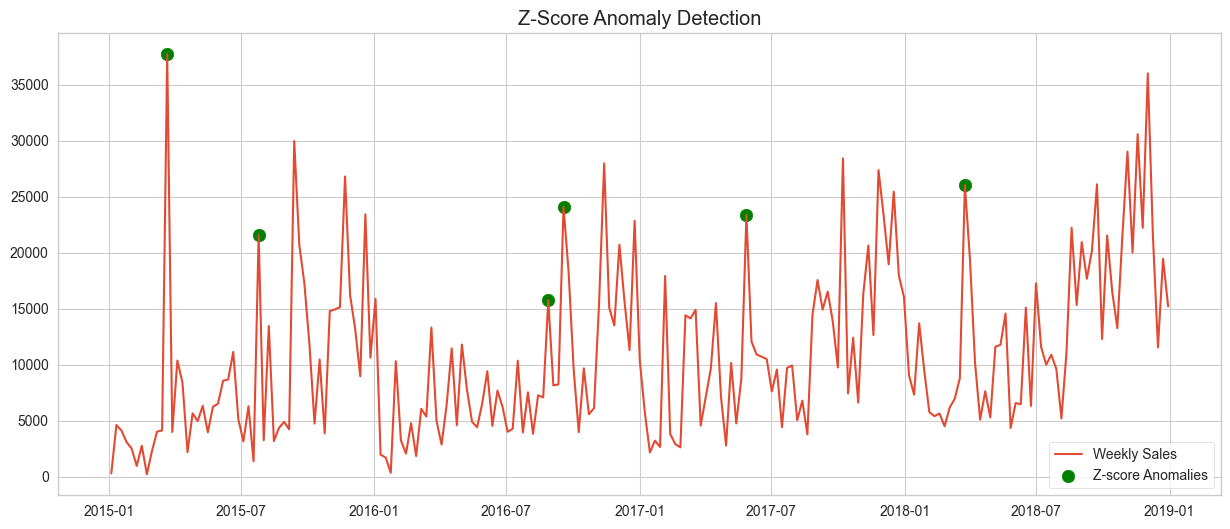

In [284]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

z = weekly_sales[
    weekly_sales["Z_Anomaly"]
]

plt.scatter(
    z["Order Date"],
    z["Sales"],
    color="green",
    s=80,
    label="Z-score Anomalies"
)

plt.legend()

plt.title("Z-Score Anomaly Detection")

plt.show()

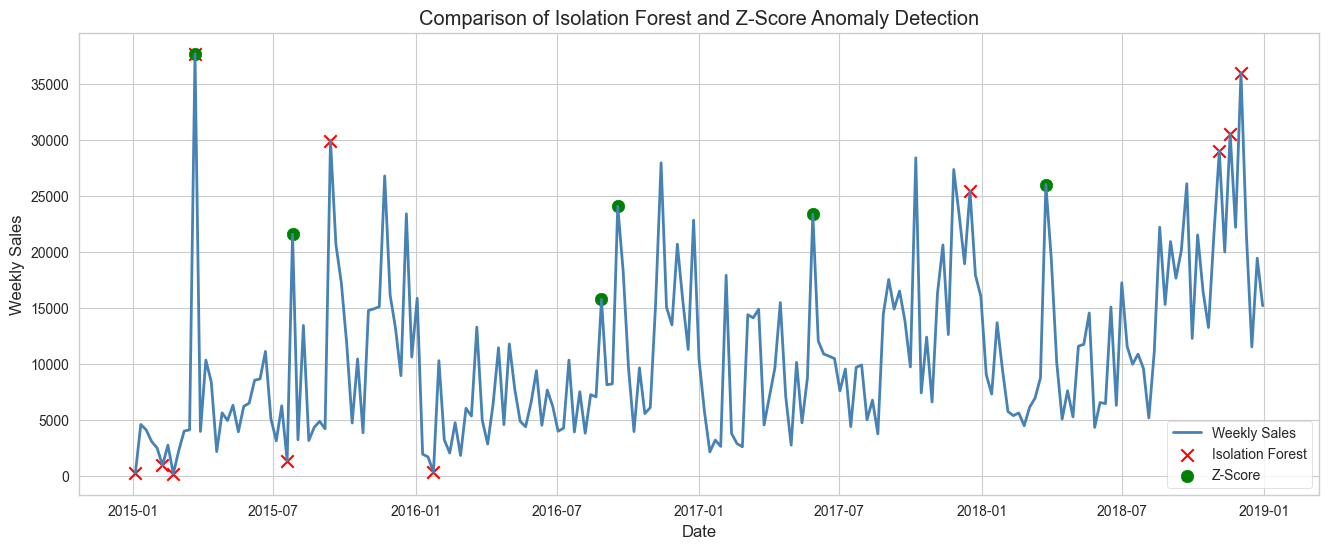

In [285]:
plt.figure(figsize=(16,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    color="steelblue",
    linewidth=2,
    label="Weekly Sales"
)

# Isolation Forest anomalies
plt.scatter(
    anomalies["Order Date"],
    anomalies["Sales"],
    color="red",
    s=80,
    marker="x",
    label="Isolation Forest"
)

# Z-Score anomalies
plt.scatter(
    z["Order Date"],
    z["Sales"],
    color="green",
    s=80,
    marker="o",
    label="Z-Score"
)

plt.title("Comparison of Isolation Forest and Z-Score Anomaly Detection")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(True)

plt.show()

In [286]:
print("Isolation Forest:",
      anomalies.shape[0])

print("Z-score:",
      z.shape[0])

Isolation Forest: 11
Z-score: 6


In [287]:
common = pd.merge(
    anomalies,
    z,
    on="Order Date"
)

common[["Order Date","Sales_x"]]

,Order Date,Sales_x
0,2015-03-22,37703.665


In [311]:
monthly_sales.to_csv("outputs/monthly_sales.csv")

In [312]:
weekly_sales.to_csv("outputs/weekly_sales.csv", index=False)

In [313]:
forecast_summary.to_csv("outputs/forecast_results.csv", index=False)

In [314]:
anomalies.to_csv("outputs/anomalies.csv", index=False)

1.The detected anomalies represent weeks where sales deviated significantly from the normal demand pattern. Large positive spikes are likely associated with seasonal shopping events such as Black Friday, Christmas, New Year promotions, or special discount campaigns. Conversely, unusually low sales weeks may correspond to post-holiday demand declines, inventory shortages, supply chain disruptions, or temporary operational issues. These unusual patterns are important because they may require different inventory and supply chain decisions compared to normal sales periods.




2.The Isolation Forest model detected 11 anomalous weeks, whereas the Z-Score method detected 6 anomalous weeks. Although both methods identified several major sales spikes, Isolation Forest detected additional anomalies that were not identified by the Z-Score method.

This difference occurs because Isolation Forest is a machine learning algorithm that isolates unusual observations based on the overall data distribution, allowing it to detect more complex anomaly patterns. In contrast, the Z-Score method relies on deviations from the rolling mean and standard deviation, making it effective primarily for identifying statistically extreme values.

Therefore, Isolation Forest is generally more sensitive to subtle or irregular anomalies, while the Z-Score method focuses on only the most significant statistical outliers.

TASK 6

In [288]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns

In [289]:
sales = df.groupby("Sub-Category")["Sales"].sum()

In [290]:
avg_order = df.groupby("Sub-Category")["Sales"].mean()

In [291]:
monthly = (
    df.groupby(
        ["Sub-Category",
         pd.Grouper(key="Order Date",freq="ME")]
    )["Sales"]
    .sum()
    .reset_index()
)

In [292]:
volatility = (
    monthly.groupby("Sub-Category")["Sales"]
    .std()
)

In [293]:
yearly = (
    df.groupby(
        ["Sub-Category","Year"]
    )["Sales"]
    .sum()
    .reset_index()
)

In [294]:
growth = (
    yearly.groupby("Sub-Category")["Sales"]
    .pct_change()
)

In [295]:
growth_rate = (
    yearly.assign(Growth=growth)
    .groupby("Sub-Category")["Growth"]
    .mean()
)

In [296]:
cluster_df = pd.DataFrame({

    "Total Sales": sales,

    "Growth Rate": growth_rate,

    "Volatility": volatility,

    "Average Order": avg_order

})

cluster_df.fillna(0,inplace=True)

cluster_df

,Total Sales,Growth Rate,Volatility,Average Order
Sub-Category,,,,
Accessories,164186.7000,0.376381,2579.994809,217.178175
Appliances,104618.4030,0.399276,1821.621539,227.926804
Art,26705.4100,0.166056,330.488343,34.019631
Binders,200028.7850,0.218736,3848.223648,134.067550
Bookcases,113813.1987,0.238065,2220.405080,503.598224
Chairs,322822.7310,0.071358,4407.232960,531.833165
Copiers,146248.0940,0.846718,5500.774391,2215.880212
Envelopes,16128.0460,-0.027666,228.218688,65.032444
Fasteners,3001.9600,0.157034,48.742229,14.027850


In [297]:
scaler = StandardScaler()

scaled = scaler.fit_transform(cluster_df)

In [298]:
inertia = []

for k in range(1,8):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(scaled)

    inertia.append(km.inertia_)

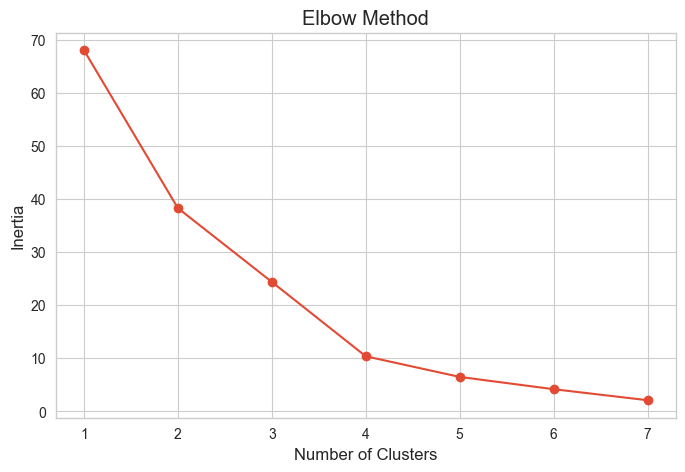

In [299]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,8),
    inertia,
    marker='o'
)

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [300]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_df["Cluster"] = kmeans.fit_predict(scaled)

In [301]:
pca = PCA(n_components=2)

components = pca.fit_transform(scaled)

cluster_df["PC1"] = components[:,0]

cluster_df["PC2"] = components[:,1]

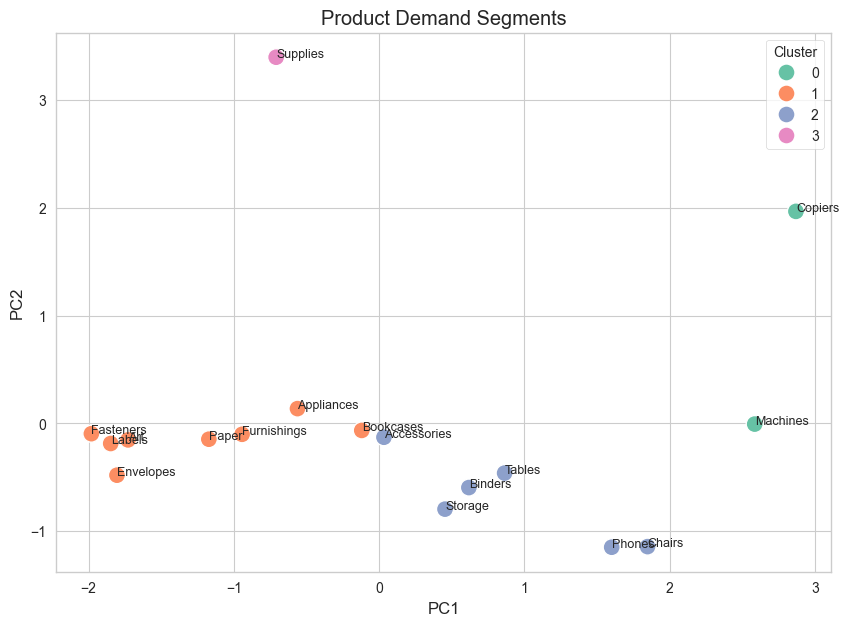

In [302]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=cluster_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=150
)

for i in range(cluster_df.shape[0]):
    plt.text(
        cluster_df["PC1"].iloc[i],
        cluster_df["PC2"].iloc[i],
        cluster_df.index[i],
        fontsize=9
    )

plt.title("Product Demand Segments")

plt.show()

In [303]:
cluster_df.sort_values("Cluster")

,Total Sales,Growth Rate,Volatility,Average Order,Cluster,PC1,PC2
Sub-Category,,,,,,,
Copiers,146248.0940,0.846718,5500.774391,2215.880212,0,2.868650,1.966394
Machines,189238.6310,0.080060,5603.554747,1645.553313,0,2.584982,-0.006099
Bookcases,113813.1987,0.238065,2220.405080,503.598224,1,-0.119791,-0.064887
Appliances,104618.4030,0.399276,1821.621539,227.926804,1,-0.562213,0.137443
Envelopes,16128.0460,-0.027666,228.218688,65.032444,1,-1.804686,-0.479931
Furnishings,89212.0180,0.287889,1360.017867,95.823865,1,-0.943515,-0.100764
Fasteners,3001.9600,0.157034,48.742229,14.027850,1,-1.980768,-0.094968
Art,26705.4100,0.166056,330.488343,34.019631,1,-1.728503,-0.152657
Paper,76828.3040,0.254131,1024.824982,57.420257,1,-1.172294,-0.146297


In [304]:
cluster_df.groupby("Cluster").mean()

,Total Sales,Growth Rate,Volatility,Average Order,PC1,PC2
Cluster,,,,,,
0,167743.362500,0.463389,5552.164569,1930.716763,2.726816,0.980147
1,55331.883212,0.199589,907.223743,129.054568,-1.269944,-0.136020
2,239495.780667,0.180965,3489.056075,361.131228,0.902476,-0.711350
3,46420.308000,1.928448,2025.094139,252.284283,-0.708934,3.395967


In [306]:
cluster_names = {

    0:"High Volume, Stable Demand",

    1:"Growing Demand",

    2:"Low Volume, High Volatility",

    3:"Declining Demand"

}

cluster_df["Demand Segment"] = (
    cluster_df["Cluster"]
    .map(cluster_names)
)

In [307]:
cluster_df[
    [
        "Total Sales",
        "Growth Rate",
        "Volatility",
        "Average Order",
        "Demand Segment"
    ]
]

,Total Sales,Growth Rate,Volatility,Average Order,Demand Segment
Sub-Category,,,,,
Accessories,164186.7000,0.376381,2579.994809,217.178175,"Low Volume, High Volatility"
Appliances,104618.4030,0.399276,1821.621539,227.926804,Growing Demand
Art,26705.4100,0.166056,330.488343,34.019631,Growing Demand
Binders,200028.7850,0.218736,3848.223648,134.067550,"Low Volume, High Volatility"
Bookcases,113813.1987,0.238065,2220.405080,503.598224,Growing Demand
Chairs,322822.7310,0.071358,4407.232960,531.833165,"Low Volume, High Volatility"
Copiers,146248.0940,0.846718,5500.774391,2215.880212,"High Volume, Stable Demand"
Envelopes,16128.0460,-0.027666,228.218688,65.032444,Growing Demand
Fasteners,3001.9600,0.157034,48.742229,14.027850,Growing Demand


Cluster 0 – High-Value, High-Volatility Products

Products: Copiers, Machines

Characteristics:

High total sales
Very high average order value
High demand fluctuations

Stocking Strategy:

Products in this cluster are expensive and experience significant fluctuations in demand. Businesses should maintain moderate inventory levels while closely monitoring demand forecasts. Since these products require substantial capital investment, excess inventory should be avoided. Demand forecasting and supplier coordination should be used to replenish stock only when necessary.

Cluster 1 – Low-Volume, Stable Demand Products

Products: Bookcases, Appliances, Envelopes, Furnishings, Fasteners, Art, Paper, Labels

Characteristics:

Lower sales volume
Lower average order value
Relatively stable demand

Stocking Strategy:

These products exhibit relatively stable but lower demand. A conservative stocking strategy is appropriate, with moderate inventory levels and regular replenishment. Overstocking should be avoided to minimize storage costs while ensuring sufficient stock to meet routine customer demand.

Cluster 2 – High-Volume, Stable Demand Products

Products: Accessories, Binders, Chairs, Phones, Storage, Tables

Characteristics:

Highest total sales
Strong and consistent demand
Good sales stability

Stocking Strategy:

This cluster represents the company's core revenue-generating products. High inventory availability should be maintained to prevent stockouts and lost sales. These products should receive the highest priority in procurement and warehouse allocation because they consistently contribute the largest share of overall sales.

Cluster 3 – Fast-Growing Products

Products: Supplies

Characteristics:

Highest growth rate
Moderate current sales
Strong future demand potential

Stocking Strategy:

Products in this cluster are experiencing rapid growth and should be monitored closely. Inventory levels should be increased gradually to support rising customer demand while continuously evaluating sales trends. Maintaining flexible supplier relationships will help accommodate future increases without creating unnecessary excess inventory.

In [316]:


cluster_df = cluster_df.reset_index()
cluster_df.to_csv("outputs/clusters.csv", index=False)

In [308]:
%pip install streamlit

  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached gitpython-3.1.50-py3-none-any.whl.metadata (14 kB)
  Using cached pyarrow-24.0.0-cp314-cp314-win_amd64.whl.metadata (3.0 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached websockets-16.0-cp314-cp314-win_amd64.whl.metadata (7.0 kB)
  Using cached itsdangerous-2.2.0-py3-none-any.whl.metadata (1.9 kB)
  Using cached watchdog-6.0.0-py3-none-win_amd64.whl.metadata (44 kB)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadata (1.2 kB)
  Using cached smmap-5.0.3-py3-none-any.whl.metadata (4.6 kB)
   ---------------------------------------- 0.0/10.3 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/10.3 MB 6.8 MB/s eta 0:00:02
   ------- -------------------------------- 1.8/10.3 MB 4.9 MB/s eta 0:00:02
   ---------- ----------------------------- 2.6/10.3 MB 4.5 MB/s eta 0:00:02
   ------------- --------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
